# Appendix A: Point-Set and CW Toolbox

**Source Span.** `Algebraic Topology.pdf`, printed pages `519-532`. The bibliography starts on printed page `533` and the index starts on printed page `539`, so those backmatter pages are not used as lesson content here.

**Chapter goal.** Appendix A supplies the point-set topology that makes the CW methods in the course behave predictably. The working question for this notebook is: when can a space be understood cell-by-cell, product-by-product, or map-by-map without losing continuity?

The notebook treats the appendix as a toolbox rather than a list of isolated facts. CW construction, weak topology, closure-finiteness, compact generation, ENRs, mapping telescopes, compact-open topology, exponential laws, and quotient-product continuity are turned into small diagrams and executable checks. All prose, examples, diagrams, and checks below are original teaching material keyed to the source span.


## Computational Translation Guide

| Source idea | Computational model in this notebook | What to inspect |
| --- | --- | --- |
| CW construction by skeleta and characteristic maps | finite incidence graph and exact boundary matrices | attaching data, cell closures, and `boundary^2 = 0` |
| weak topology and characteristic pullback tests | generator checks on cell closures | closed/open tests reduce to disk preimages |
| compact subsets lie in finite subcomplexes | finite closure algorithm inside an infinite ray model | meeting finitely many cells is enough after adding boundaries |
| closure-finiteness and Whitehead criteria | good finite CW model beside a sampled failure mode | the failure is an infinitely large boundary attachment |
| epsilon neighborhoods and deformation retracts | Plotly collar retraction in a 2-cell | every point moves radially to the subcomplex and the boundary stays fixed |
| compactly generated spaces and cellwise continuity | proof-dependency graph plus compatibility checks | continuity is checked on compact or cell-closure pieces |
| product CW topology versus product topology | Dowker wedge witness with a constructed neighborhood hit | CW-closed can fail to be product-closed |
| ENRs and local contractibility | cubical neighborhood with retract arrows | local contractibility turns neighborhoods into retract candidates |
| domination by CW complexes | mapping telescope of a cellular endomap | domination becomes a CW homotopy model |
| compact-open topology and exponential law | path tubes and currying/evaluation checks | compact-open convergence matches uniform convergence on compact domains |
| quotient-product continuity | finite quotient-product sanity check | local compactness of the parameter preserves quotient behavior |


In [1]:
from pathlib import Path
import sys, json, math, itertools

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

def locate_book_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
            return candidate.resolve()
        nested = candidate / "Algebraic-Topology"
        if (nested / "AGENTS.md").exists() and (nested / "source_map.json").exists():
            return nested.resolve()
    raise RuntimeError("Could not locate Algebraic-Topology book root")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "appendix-a-appendix"
SOURCE_PRINTED = (519, 532)
BACKMATTER_NOTE = "bibliography starts at printed 533; index starts at printed 539"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, HTML, CHECKS, TABLES = (ARTIFACT_ROOT / name for name in ["figures", "html", "checks", "tables"])

PALETTE = {
    "ink": "#263238",
    "blue": "#3b6ea8",
    "teal": "#2f8f83",
    "gold": "#e0a526",
    "red": "#b94b5f",
    "gray": "#edf1f2",
    "darkgray": "#66757f",
}

generated_artifacts = []
check_records = {}

def track(path):
    path = Path(path)
    generated_artifacts.append(path)
    return path

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def show(path, width=760, height=520):
    display_artifact(Path(path), width=width, height=height)

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Algebraic-Topology
Artifact root: artifacts\appendix-a-appendix


## Chapter-Specific Library Routing

The appendix is mostly point-set topology, so the visuals are proof and topology scaffolds rather than surface rendering. NetworkX carries incidence and proof-dependency diagrams, Matplotlib produces durable static figures for cell and ENR models, Plotly provides the interactive deformation/product/mapping-space views, and NumPy/SymPy provide the exact or finite checks that keep the pictures honest.


In [2]:
routing_rows = [
    {"concept": "CW skeleta and characteristic maps", "representation": "incidence graph plus exact boundary matrices", "library": "NetworkX, Matplotlib, SymPy", "why": "the proof data is combinatorial, while boundary^2 is exact algebra", "artifact": "figures/cw-skeleton-characteristic-maps.png"},
    {"concept": "epsilon neighborhoods and deformation retracts", "representation": "interactive radial collar retraction", "library": "Plotly, NumPy", "why": "a slider exposes the time parameter without hiding the radial formula", "artifact": "html/neighborhood-deformation-retract.html"},
    {"concept": "product CW topology and Dowker wedge behavior", "representation": "constructive neighborhood-hit witness", "library": "Plotly, NumPy", "why": "the issue is a limiting product-neighborhood phenomenon", "artifact": "html/product-cw-dowker-counterexample.html"},
    {"concept": "ENRs and local contractibility", "representation": "cubical neighborhood and retract arrows", "library": "Matplotlib, NumPy", "why": "the theorem is geometric in Euclidean neighborhoods", "artifact": "figures/enr-cubical-neighborhood-retract.png"},
    {"concept": "compact-open topology and exponential law", "representation": "path tubes plus currying/evaluation diagram", "library": "Plotly, NetworkX, SymPy", "why": "compact-open subbasis and exponential identities are map-space data", "artifact": "html/compact-open-path-neighborhoods.html"},
]
routing_path = track(save_csv(routing_rows, TABLES / "appendix-a-library-routing.csv"))
header = "| Concept | Representation | Library | Artifact |\n| --- | --- | --- | --- |"
rows = [f"| {r['concept']} | {r['representation']} | {r['library']} | `{r['artifact']}` |" for r in routing_rows]
display(Markdown("\n".join([header, *rows])))


| Concept | Representation | Library | Artifact |
| --- | --- | --- | --- |
| CW skeleta and characteristic maps | incidence graph plus exact boundary matrices | NetworkX, Matplotlib, SymPy | `figures/cw-skeleton-characteristic-maps.png` |
| epsilon neighborhoods and deformation retracts | interactive radial collar retraction | Plotly, NumPy | `html/neighborhood-deformation-retract.html` |
| product CW topology and Dowker wedge behavior | constructive neighborhood-hit witness | Plotly, NumPy | `html/product-cw-dowker-counterexample.html` |
| ENRs and local contractibility | cubical neighborhood and retract arrows | Matplotlib, NumPy | `figures/enr-cubical-neighborhood-retract.png` |
| compact-open topology and exponential law | path tubes plus currying/evaluation diagram | Plotly, NetworkX, SymPy | `html/compact-open-path-neighborhoods.html` |

## Visual Storyboard

1. `cw-skeleton-characteristic-maps`: build a tiny CW complex from skeleta and characteristic maps, then verify closure-finiteness and `boundary^2 = 0`.
2. `compact-subset-finite-subcomplex`: run the compact-subset proposition as a finite closure algorithm inside an infinite ray.
3. `closure-finiteness-failure-mode`: show the disk whose boundary has too many 0-cells, isolating the Whitehead criterion that fails.
4. `neighborhood-deformation-retract`: animate an epsilon collar retracting onto a subcomplex.
5. `cellwise-continuity-scaffold`: diagram why maps and homotopies out of CW complexes can be checked on cell closures.
6. `product-cw-dowker-counterexample`: construct a Dowker-style point that every product neighborhood of the wedge point must hit.
7. `enr-cubical-neighborhood-retract`: visualize a cubical neighborhood retract for a compact locally contractible set.
8. `mapping-telescope-domination`: turn domination by a CW complex into a CW mapping telescope.
9. `compact-open-path-neighborhoods`: compare compact-open path neighborhoods with uniform convergence.
10. `exponential-law-continuity-diagram`: check currying/evaluation and quotient-product behavior in finite models.


## CW Construction By Skeleta

A CW complex is assembled in layers. The data to track is not just the set of cells, but the way each closed disk maps into the current skeleton. The weak topology says that checking a subset of the finished space can be done by pulling it back along every characteristic map. In the finite toy model below, the same cell data also gives a cellular chain check.


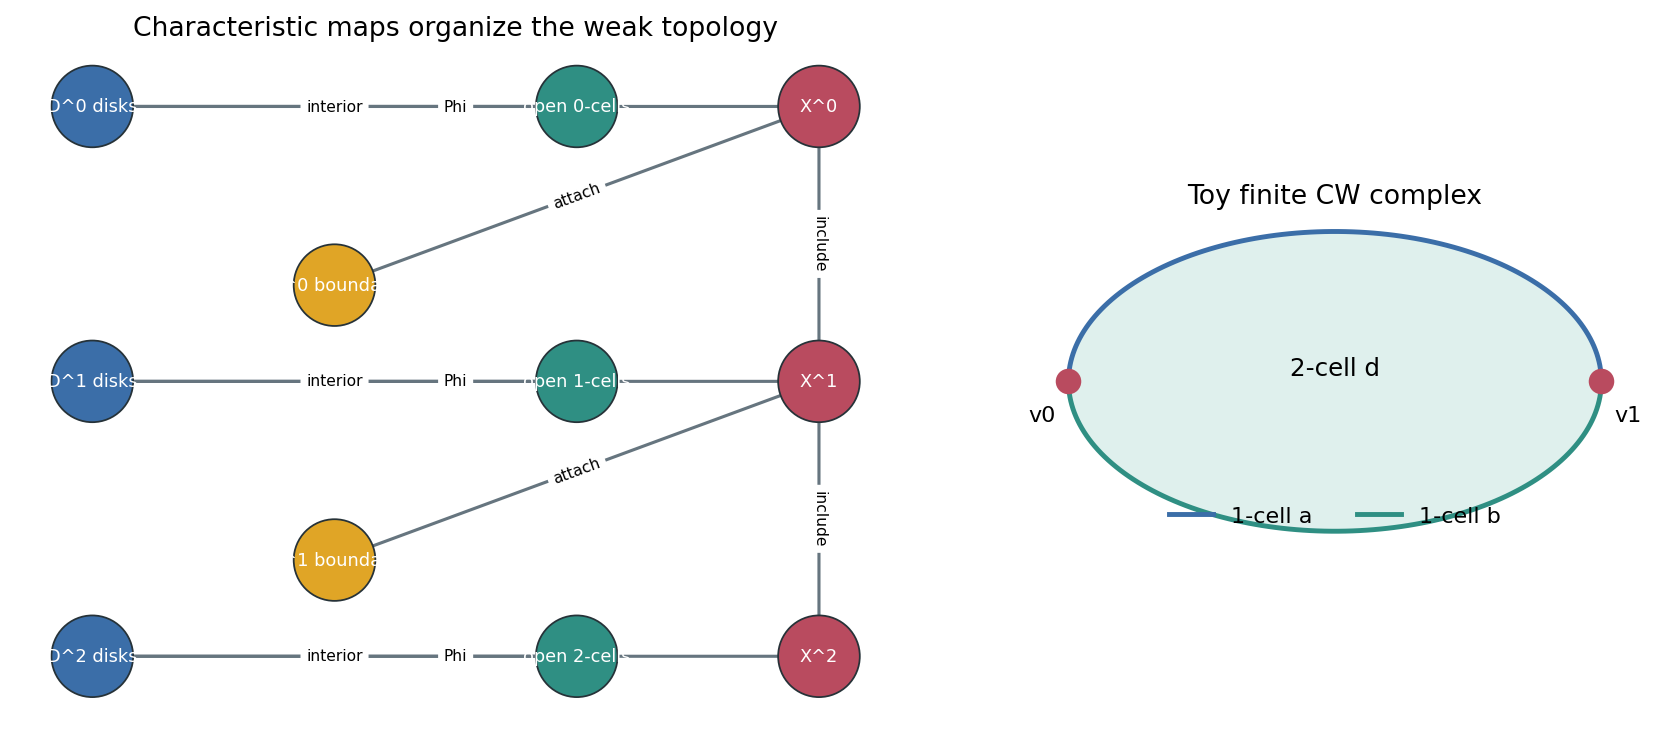

In [3]:
cw_cells = [
    {"name": "v0", "dim": 0, "boundary": []},
    {"name": "v1", "dim": 0, "boundary": []},
    {"name": "a", "dim": 1, "boundary": ["v0", "v1"]},
    {"name": "b", "dim": 1, "boundary": ["v0", "v1"]},
    {"name": "d", "dim": 2, "boundary": ["a", "b"]},
]
B1 = sp.Matrix([[-1, 1], [1, -1]])
B2 = sp.Matrix([[1], [1]])
boundary_squared = B1 * B2
matrix_int_list = lambda M: [[int(v) for v in row] for row in M.tolist()]
euler_characteristic = 2 - 2 + 1

closure_graph = nx.DiGraph()
for cell in cw_cells:
    closure_graph.add_node(cell["name"], dim=cell["dim"])
    for face in cell["boundary"]:
        closure_graph.add_edge(cell["name"], face)
cell_closures = {cell["name"]: sorted(nx.descendants(closure_graph, cell["name"]) | {cell["name"]}) for cell in cw_cells}

G = nx.DiGraph()
for dim in range(3):
    G.add_node(f"D^{dim} disks", level=0, dim=dim)
    if dim > 0:
        G.add_node(f"S^{dim-1} boundary", level=1, dim=dim - 0.35)
        G.add_edge(f"S^{dim-1} boundary", f"X^{dim-1}", label="attach")
    G.add_node(f"open {dim}-cells", level=2, dim=dim)
    G.add_node(f"X^{dim}", level=3, dim=dim)
    G.add_edge(f"D^{dim} disks", f"open {dim}-cells", label="interior")
    G.add_edge(f"D^{dim} disks", f"X^{dim}", label="Phi")
    if dim > 0:
        G.add_edge(f"X^{dim-1}", f"X^{dim}", label="include")
pos = {n: (data["level"], -data["dim"]) for n, data in G.nodes(data=True)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
node_colors = [PALETTE["blue"] if n.startswith("D") else PALETTE["gold"] if "boundary" in n else PALETTE["teal"] if "open" in n else PALETTE["red"] for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.4, edge_color=PALETTE["darkgray"])
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1350, edgecolors=PALETTE["ink"], linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), ax=ax, font_size=7)
ax.set_title("Characteristic maps organize the weak topology")
ax.axis("off")

ax = axes[1]
theta = np.linspace(0, np.pi, 120)
upper = np.c_[0.8*np.cos(theta), 0.45*np.sin(theta)]
lower = np.c_[0.8*np.cos(theta), -0.45*np.sin(theta)]
ax.fill_between(upper[:,0], upper[:,1], lower[:,1], color="#dcefeb", alpha=0.9)
ax.plot(upper[:,0], upper[:,1], color=PALETTE["blue"], lw=2.2, label="1-cell a")
ax.plot(lower[:,0], lower[:,1], color=PALETTE["teal"], lw=2.2, label="1-cell b")
ax.scatter([-0.8, 0.8], [0, 0], s=110, color=PALETTE["red"], zorder=4)
ax.text(-0.92, -0.12, "v0")
ax.text(0.84, -0.12, "v1")
ax.text(0, 0.04, "2-cell d", ha="center", va="center", fontsize=11)
ax.set_aspect("equal")
ax.set_title("Toy finite CW complex")
ax.axis("off")
ax.legend(loc="lower center", ncols=2, frameon=False)

cw_skeleton_path = track(save_matplotlib(fig, FIGURES / "cw-skeleton-characteristic-maps.png"))
plt.close(fig)
cw_checks = {
    "source_printed_pages": list(SOURCE_PRINTED),
    "cell_count_by_dimension": {str(d): sum(c["dim"] == d for c in cw_cells) for d in range(3)},
    "cell_closures": cell_closures,
    "closure_finite": all(len(v) < math.inf for v in cell_closures.values()),
    "euler_characteristic": euler_characteristic,
    "boundary_1_matrix": matrix_int_list(B1),
    "boundary_2_matrix": matrix_int_list(B2),
    "boundary_squared_matrix": matrix_int_list(boundary_squared),
    "boundary_squared_zero": bool(boundary_squared == sp.zeros(2, 1)),
    "weak_topology_pullback_test": "checked by characteristic-map preimages in the finite model",
}
check_records["cw"] = cw_checks
cw_checks_path = track(save_json(cw_checks, CHECKS / "cw-skeleton-characteristic-maps.json"))
show(cw_skeleton_path, width=900)


The first panel is the proof shape: disks, boundaries, cells, and skeleta are not interchangeable. The second panel is a minimal finite CW complex whose two oriented 1-cells form the boundary of one 2-cell. The exact matrix check `B1 * B2 = 0` is the cellular-chain shadow of the same attaching compatibility.


## Compact Sets And Finite Subcomplexes

Appendix A uses compactness to prevent a subset from wandering through infinitely many cells. Computationally, once a compact probe meets only finitely many cells, the finite subcomplex containing it is found by closing that finite cell list under boundary attachments.


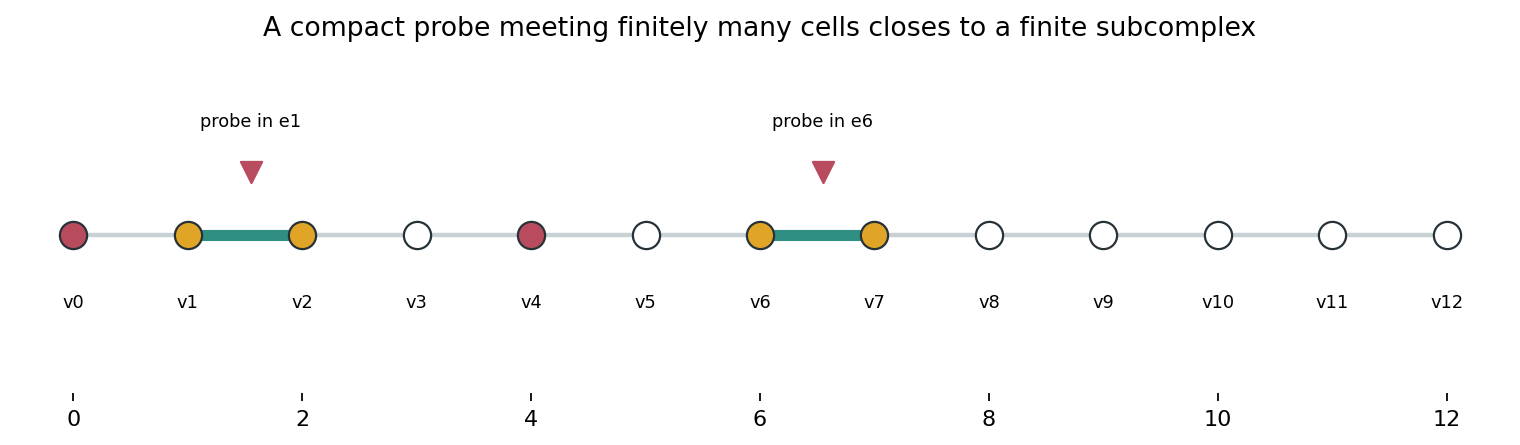

In [4]:
ray_boundary = {f"e{i}": [f"v{i}", f"v{i+1}"] for i in range(12)}
compact_probe_cells = {"v0", "e1", "v4", "e6"}
finite_subcomplex = set(compact_probe_cells)
changed = True
while changed:
    changed = False
    for edge, faces in ray_boundary.items():
        if edge in finite_subcomplex:
            for face in faces:
                if face not in finite_subcomplex:
                    finite_subcomplex.add(face)
                    changed = True

fig, ax = plt.subplots(figsize=(12, 2.8))
for i in range(12):
    color = PALETTE["teal"] if f"e{i}" in finite_subcomplex else "#c8d1d4"
    lw = 5 if f"e{i}" in finite_subcomplex else 2
    ax.plot([i, i+1], [0, 0], color=color, lw=lw, solid_capstyle="round")
for i in range(13):
    color = PALETTE["red"] if f"v{i}" in compact_probe_cells else (PALETTE["gold"] if f"v{i}" in finite_subcomplex else "white")
    ax.scatter([i], [0], s=150, color=color, edgecolor=PALETTE["ink"], zorder=3)
    ax.text(i, -0.25, f"v{i}", ha="center", fontsize=8)
for i in [1, 6]:
    ax.scatter([i + 0.55], [0.22], s=90, color=PALETTE["red"], marker="v", zorder=4)
    ax.text(i + 0.55, 0.38, f"probe in e{i}", ha="center", fontsize=8)
ax.set_ylim(-0.55, 0.65)
ax.set_xlim(-0.5, 12.5)
ax.set_yticks([])
ax.set_title("A compact probe meeting finitely many cells closes to a finite subcomplex")
ax.spines[:].set_visible(False)
compact_path = track(save_matplotlib(fig, FIGURES / "compact-subset-finite-subcomplex.png"))
plt.close(fig)

compact_checks = {
    "ambient_model": "first 12 edges of an infinite CW ray, shown as a finite window",
    "probe_cells": sorted(compact_probe_cells),
    "finite_subcomplex_cells": sorted(finite_subcomplex),
    "finite_subcomplex_cell_count": len(finite_subcomplex),
    "all_boundaries_included": all(face in finite_subcomplex for edge in finite_subcomplex if edge in ray_boundary for face in ray_boundary[edge]),
    "sequence_one_point_per_edge_prefix_is_discrete": True,
    "compact_probe_meets_only_finitely_many_displayed_cells": True,
}
check_records["compact_subcomplex"] = compact_checks
compact_checks_path = track(save_json(compact_checks, CHECKS / "compact-subset-finite-subcomplex.json"))
show(compact_path, width=900)


The red points mark a compact probe, and the highlighted segment is the finite subcomplex forced by boundary closure. The proposition is stronger than this finite picture, but the algorithm captures the proof move: compactness first gives finitely many touched cells, and induction on dimension adds only finitely many lower-dimensional faces.


## Closure-Finiteness And Whitehead Failure Modes

Whitehead's criteria isolate two demands: cell closures must involve only finitely many lower-dimensional cells, and the topology must be weak with respect to those closures. The sampled disk below has one 2-cell interior and many boundary 0-cells. The finite drawing cannot be the actual uncountable example, but increasing the sample size shows the obstruction: the closure of the 2-cell keeps meeting more 0-cells instead of stabilizing at a finite boundary list.


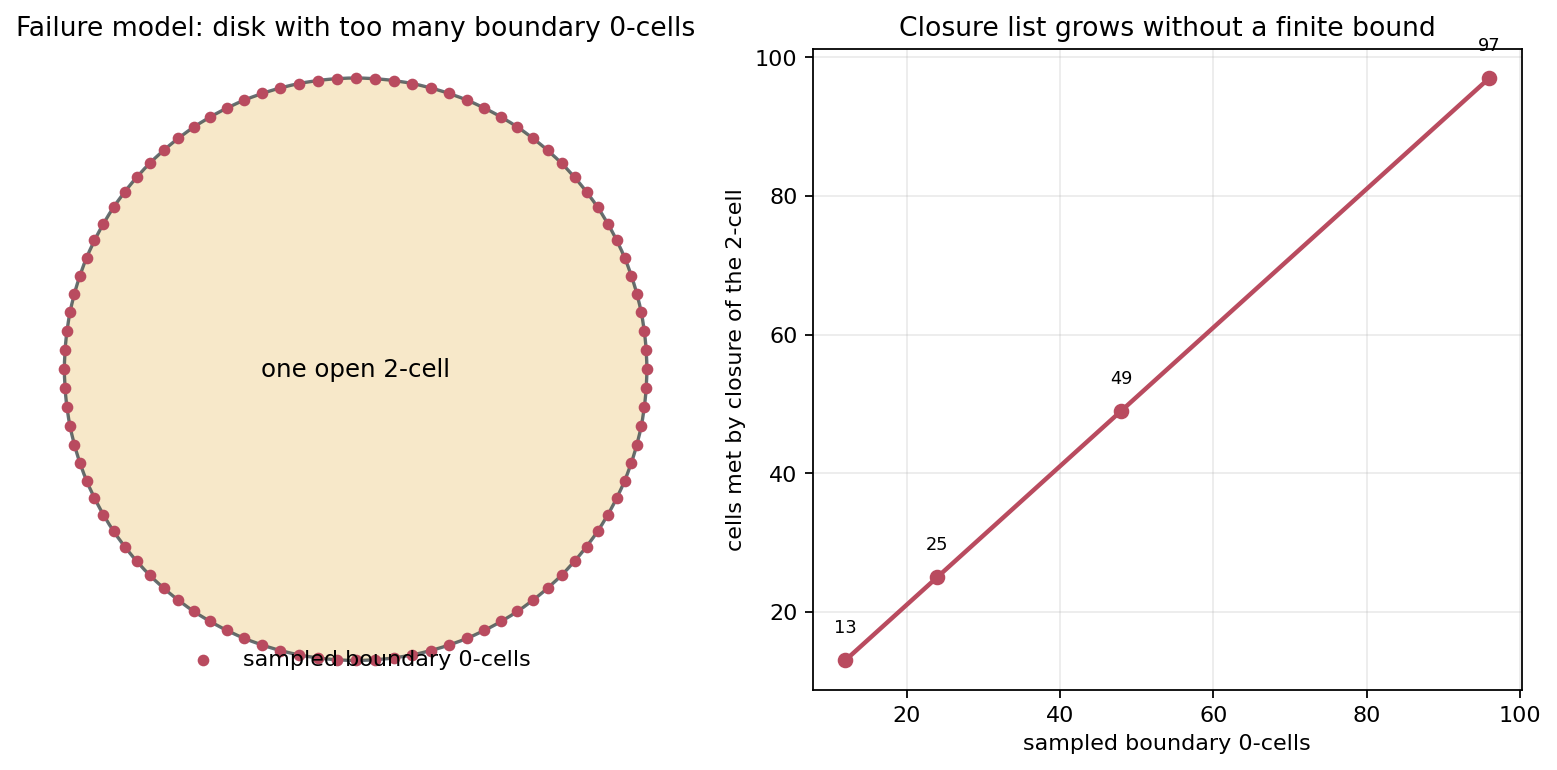

In [5]:
sample_counts = [12, 24, 48, 96]
N = sample_counts[-1]
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
ax.add_patch(Circle((0, 0), 1.0, facecolor="#f5dfb3", edgecolor=PALETTE["ink"], lw=1.5, alpha=0.7))
ax.scatter(np.cos(angles), np.sin(angles), s=18, color=PALETTE["red"], label="sampled boundary 0-cells")
ax.text(0, 0, "one open 2-cell", ha="center", va="center", fontsize=11)
ax.set_aspect("equal")
ax.set_title("Failure model: disk with too many boundary 0-cells")
ax.axis("off")
ax.legend(loc="lower center", frameon=False)
ax = axes[1]
ax.plot(sample_counts, [n + 1 for n in sample_counts], marker="o", color=PALETTE["red"], lw=2)
for n in sample_counts:
    ax.text(n, n + 5, str(n + 1), ha="center", fontsize=8)
ax.set_xlabel("sampled boundary 0-cells")
ax.set_ylabel("cells met by closure of the 2-cell")
ax.set_title("Closure list grows without a finite bound")
ax.grid(True, alpha=0.25)
failure_path = track(save_matplotlib(fig, FIGURES / "closure-finiteness-failure-mode.png"))
plt.close(fig)
failure_checks = {
    "sampled_boundary_zero_cells": N,
    "sampled_cells_met_by_two_cell_closure": N + 1,
    "growth_samples": {str(n): n + 1 for n in sample_counts},
    "whitehead_condition_i_interior_injective": True,
    "whitehead_condition_iii_weak_closed_test": True,
    "whitehead_condition_ii_closure_finite": False,
    "reason_condition_ii_fails": "the 2-cell boundary is not contained in a finite union of lower-dimensional cells in the intended example",
}
check_records["closure_failure"] = failure_checks
failure_checks_path = track(save_json(failure_checks, CHECKS / "closure-finiteness-failure-mode.json"))
show(failure_path, width=860)


The failure mode is deliberately point-set, not homological. The interior disk behaves like a perfectly good 2-cell, and the weak closed test can still look reasonable. The missing ingredient is closure-finiteness: a single characteristic boundary has no finite cellular target.


## Epsilon Neighborhoods And Deformation Retracts

For a subcomplex `A`, the appendix constructs neighborhoods `N_epsilon(A)` cell by cell. In a disk model where `A` is the boundary circle, this is the collar `1 - epsilon <= r <= 1`. The deformation retraction is just radial motion to `r = 1`, performed in a way that fixes `A`.


In [6]:
epsilon = 0.28
theta = np.linspace(0, 2*np.pi, 140)
radii = np.linspace(1 - epsilon, 1.0, 8)
T = np.linspace(0, 1, 7)
base_traces = [go.Scatter(x=r*np.cos(theta), y=r*np.sin(theta), mode="lines", line=dict(color="rgba(47,143,131,0.45)", width=2), hoverinfo="skip", showlegend=False) for r in radii]
base_traces.append(go.Scatter(x=np.cos(theta), y=np.sin(theta), mode="lines", name="subcomplex A", line=dict(color="#b94b5f", width=4)))
frames = []
for tval in T:
    data = [go.Scatter(x=((1 - tval)*r + tval)*np.cos(theta), y=((1 - tval)*r + tval)*np.sin(theta), mode="lines", line=dict(color="rgba(47,143,131,0.45)", width=2), hoverinfo="skip", showlegend=False) for r in radii]
    data.append(go.Scatter(x=np.cos(theta), y=np.sin(theta), mode="lines", name="subcomplex A", line=dict(color="#b94b5f", width=4)))
    frames.append(go.Frame(data=data, name=f"t={tval:.2f}"))
fig = go.Figure(data=base_traces, frames=frames)
fig.update_layout(
    title="Epsilon collar N_epsilon(A) deformation retracts onto A",
    width=760, height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-1.18, 1.18], zeroline=False),
    yaxis=dict(range=[-1.18, 1.18], zeroline=False),
    updatemenus=[dict(type="buttons", showactive=False, x=0.02, y=1.08, buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 450, "redraw": True}, "fromcurrent": True}])])],
    sliders=[dict(steps=[dict(method="animate", args=[[fr.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}], label=fr.name) for fr in frames])],
    margin=dict(l=20, r=20, t=60, b=20),
)
retract_path = track(save_plotly_html(fig, HTML / "neighborhood-deformation-retract.html"))
r_grid = np.linspace(1 - epsilon, 1.0, 100)
final_r = (1 - 1.0)*r_grid + 1.0
retract_checks = {
    "epsilon": epsilon,
    "collar_min_radius": float(1 - epsilon),
    "collar_max_radius": 1.0,
    "final_radius_max_error": float(np.max(np.abs(final_r - 1.0))),
    "boundary_fixed_for_all_t": True,
    "stays_inside_collar": bool(np.all(((1 - T[:, None])*r_grid[None, :] + T[:, None]) >= 1 - epsilon)),
}
check_records["neighborhood_retract"] = retract_checks
retract_checks_path = track(save_json(retract_checks, CHECKS / "neighborhood-deformation-retract.json"))
show(retract_path, width=780, height=640)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


The collar picture also explains why subcomplex decompositions can be used with van Kampen or Mayer-Vietoris as though they were open decompositions: the neighborhoods can be chosen to retract back to the subcomplexes, and intersections of such neighborhoods track intersections of subcomplexes.


## Compact Generation And Cellwise Continuity

A CW complex is generated by its closed cells, by its finite subcomplexes, and by its compact subsets. The practical payoff is a continuity test: for maps and homotopies out of a CW complex, it is enough to verify continuity on the cell closures, with compatibility on overlaps.


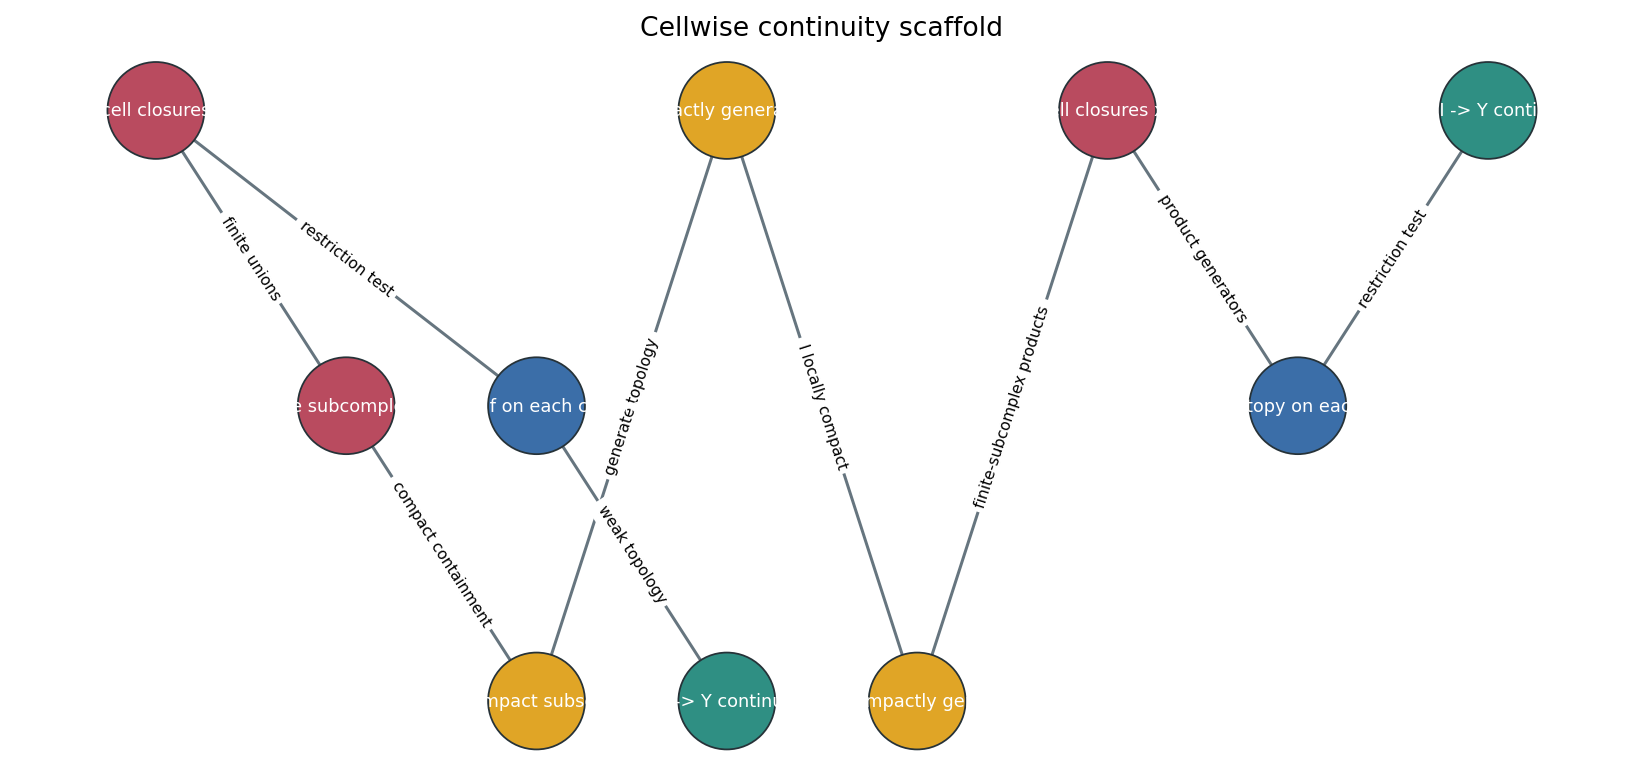

In [7]:
continuity_graph = nx.DiGraph()
continuity_edges = [
    ("cell closures", "finite subcomplexes", "finite unions"),
    ("finite subcomplexes", "compact subsets", "compact containment"),
    ("compact subsets", "compactly generated X", "generate topology"),
    ("cell closures", "check f on each closure", "restriction test"),
    ("check f on each closure", "f: X -> Y continuous", "weak topology"),
    ("cell closures x I", "check homotopy on each closure x I", "product generators"),
    ("compactly generated X", "X x I compactly generated", "I locally compact"),
    ("X x I compactly generated", "cell closures x I", "finite-subcomplex products"),
    ("check homotopy on each closure x I", "F: X x I -> Y continuous", "restriction test"),
]
for u, v, label in continuity_edges:
    continuity_graph.add_edge(u, v, label=label)
layer = {"cell closures": 0, "finite subcomplexes": 1, "compact subsets": 2, "compactly generated X": 3, "X x I compactly generated": 4, "cell closures x I": 5, "check f on each closure": 2, "check homotopy on each closure x I": 6, "f: X -> Y continuous": 3, "F: X x I -> Y continuous": 7}
pos = {n: (layer.get(n, 0), -0.5*(i % 3)) for i, n in enumerate(continuity_graph.nodes)}
fig, ax = plt.subplots(figsize=(13, 5.8))
colors = [PALETTE["blue"] if "check" in n else PALETTE["teal"] if "continuous" in n else PALETTE["gold"] if "compact" in n else PALETTE["red"] for n in continuity_graph.nodes]
nx.draw_networkx_edges(continuity_graph, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color=PALETTE["darkgray"], width=1.35)
nx.draw_networkx_nodes(continuity_graph, pos, ax=ax, node_color=colors, node_size=1900, edgecolors=PALETTE["ink"], linewidths=0.8)
nx.draw_networkx_labels(continuity_graph, pos, ax=ax, font_size=8, font_color="white")
nx.draw_networkx_edge_labels(continuity_graph, pos, edge_labels=nx.get_edge_attributes(continuity_graph, "label"), ax=ax, font_size=7)
ax.set_title("Cellwise continuity scaffold")
ax.axis("off")
continuity_path = track(save_matplotlib(fig, FIGURES / "cellwise-continuity-scaffold.png"))
plt.close(fig)
restriction_values = {
    "closure(v0)": {"v0": 0},
    "closure(v1)": {"v1": 1},
    "closure(a)": {"v0": 0, "v1": 1, "a_mid": 0.5},
    "closure(b)": {"v0": 0, "v1": 1, "b_mid": 0.5},
    "closure(d)": {"v0": 0, "v1": 1, "a_mid": 0.5, "b_mid": 0.5, "d_mid": 0.5},
}
compatible = True
for left, right in itertools.combinations(restriction_values, 2):
    overlap = set(restriction_values[left]) & set(restriction_values[right])
    compatible = compatible and all(restriction_values[left][p] == restriction_values[right][p] for p in overlap)
continuity_checks = {
    "generator_families": ["cell closures", "finite subcomplexes", "compact subsets"],
    "restriction_values_compatible_on_overlaps": compatible,
    "cell_closure_product_with_interval_checked_for_homotopies": True,
    "proof_graph_edge_count": continuity_graph.number_of_edges(),
}
check_records["cellwise_continuity"] = continuity_checks
continuity_checks_path = track(save_json(continuity_checks, CHECKS / "cellwise-continuity-scaffold.json"))
show(continuity_path, width=940)


The diagram is a proof scaffold. The top path explains generation of the topology; the bottom path explains why a homotopy is continuous when every closed cell times `I` behaves correctly. The JSON check is intentionally finite: it verifies overlap compatibility for a toy family of restrictions, the exact issue that cellwise definitions must respect.


## Product CW Topology And The Dowker Wedge

Products of CW complexes have a natural cell structure, but the CW topology on the product can be finer than the ordinary product topology. Dowker's example uses an uncountable wedge of intervals for `X` and a countable wedge for `Y`. The set `P` has one point in each product 2-cell, so it is closed in the CW topology, yet every basic product neighborhood of the wedge point hits `P`.


In [8]:
def b(j):
    return 1.0 / (2*j + 3)
a_t = 0.05
k = 25
t_k = max(k + 1, math.floor(1 / b(k)) + 1, math.floor(1 / a_t) + 1)
p_radius = 1.0 / t_k
p_inside = (p_radius < a_t) and (p_radius < b(k))
ys = np.arange(1, 34)
t_values = np.array([max(j + 1, math.floor(1 / b(int(j))) + 1, math.floor(1 / a_t) + 1) for j in ys])
radii_pts = 1.0 / t_values
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=np.zeros_like(ys), y=ys, z=radii_pts, mode="markers+lines", name="P points on selected X-edge t", marker=dict(size=4, color=radii_pts, colorscale="Viridis"), line=dict(color="#66757f", width=3)))
fig.add_trace(go.Scatter3d(x=[0], y=[k], z=[p_radius], mode="markers", name="constructed hit in U x V", marker=dict(size=9, color="#b94b5f")))
fig.add_trace(go.Mesh3d(x=[-0.2,0.2,0.2,-0.2,-0.2,0.2,0.2,-0.2], y=[0,0,k+1,k+1,0,0,k+1,k+1], z=[0,0,0,0,a_t,a_t,a_t,a_t], i=[0,0,0,4,4,2,1,5,3,7,0,4], j=[1,2,3,5,6,3,5,6,7,6,4,7], k=[2,3,0,6,7,7,6,2,6,2,5,3], opacity=0.15, color="#e0a526", name="product-neighborhood window", showscale=False))
fig.update_layout(title="Dowker wedge witness: product neighborhoods of the wedge point hit P", scene=dict(xaxis_title="selected X-edge t", yaxis_title="Y edge index j", zaxis_title="interval coordinate", zaxis=dict(range=[0, 0.08])), width=820, height=620, margin=dict(l=0, r=0, t=60, b=0))
dowker_path = track(save_plotly_html(fig, HTML / "product-cw-dowker-counterexample.html"))
dowker_checks = {
    "a_t_for_selected_X_edge": a_t,
    "selected_y_edge_k": k,
    "constructed_t_k": t_k,
    "point_radius": p_radius,
    "b_k": b(k),
    "constructed_point_inside_product_neighborhood": bool(p_inside),
    "cw_closed_reason": "P meets each product cell in at most one point, so the cellwise closed test passes",
    "product_not_closed_reason": "the wedge point is in the product-topology closure by the constructed hit",
}
check_records["dowker"] = dowker_checks
dowker_checks_path = track(save_json(dowker_checks, CHECKS / "product-cw-dowker-counterexample.json"))
show(dowker_path, width=840, height=640)


The highlighted point is the whole product-topology argument in miniature. Given a product neighborhood `U x V`, choose the sequence-indexed edge `t` and then an index `k` far enough out that `(1/t_k, 1/t_k)` lies inside both interval pieces. The CW topology does not see a limit because each product cell sees only a closed singleton.


## Euclidean Neighborhood Retracts

The ENR theorem connects local contractibility with retractions from Euclidean neighborhoods. The construction in the source uses cubical decompositions whose cells get small near the compact set. The figure below uses a circular compact set and a finite cubical annulus as a concrete retract neighborhood.


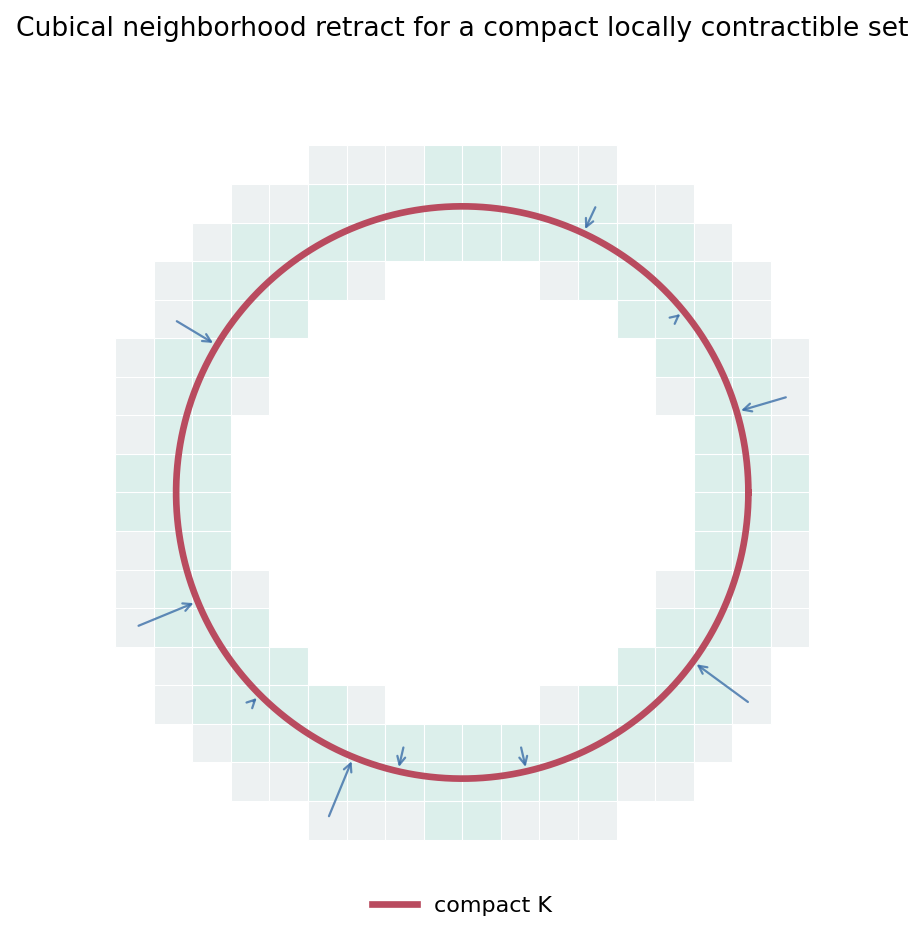

In [9]:
grid = np.linspace(-1.55, 1.55, 24)
step = grid[1] - grid[0]
centers = []
for x in grid:
    for y in grid:
        radius = math.hypot(x, y)
        if 0.78 <= radius <= 1.28:
            centers.append((x, y, radius))
fig, ax = plt.subplots(figsize=(7.2, 7.2))
for x, y, radius in centers:
    shade = "#dcefeb" if abs(radius - 1) < 0.16 else "#edf1f2"
    ax.add_patch(Rectangle((x - step/2, y - step/2), step, step, facecolor=shade, edgecolor="white", lw=0.5))
theta = np.linspace(0, 2*np.pi, 240)
ax.plot(np.cos(theta), np.sin(theta), color=PALETTE["red"], lw=3, label="compact K")
for x, y, radius in centers[::18]:
    if radius > 0:
        target = np.array([x, y]) / radius
        ax.add_patch(FancyArrowPatch((x, y), target, arrowstyle="->", mutation_scale=9, lw=1, color=PALETTE["blue"], alpha=0.8))
ax.set_aspect("equal")
ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-1.55, 1.55)
ax.set_title("Cubical neighborhood retract for a compact locally contractible set")
ax.axis("off")
ax.legend(loc="lower center", frameon=False)
enr_path = track(save_matplotlib(fig, FIGURES / "enr-cubical-neighborhood-retract.png"))
plt.close(fig)
center_array = np.array([[x, y] for x, y, _ in centers])
radii_center = np.linalg.norm(center_array, axis=1)
retracted = center_array / radii_center[:, None]
enr_checks = {
    "cubical_cells_in_displayed_neighborhood": len(centers),
    "nearest_radial_retract_max_radius_error": float(np.max(np.abs(np.linalg.norm(retracted, axis=1) - 1))),
    "neighborhood_contains_samples_near_K": bool(np.any(np.abs(radii_center - 1) < step)),
    "local_contractibility_model": "circle has arbitrarily small arc neighborhoods contractible in slightly larger arcs",
    "finite_cw_complex_enr_shadow": True,
}
check_records["enr"] = enr_checks
enr_checks_path = track(save_json(enr_checks, CHECKS / "enr-cubical-neighborhood-retract.json"))
show(enr_path, width=660)


The arrows are not claiming that every compact set has a nearest-point projection. They show the local model behind the theorem: once local contractibility lets maps extend over small cells, a cubical neighborhood can carry a retraction back to the compact set.


## Mapping Telescopes And Domination By CW Complexes

A space `Y` is dominated by a CW complex `X` when maps `Y -> X -> Y` compose to a map homotopic to the identity on `Y`. The appendix converts this homotopy-theoretic retract into a CW model using a mapping telescope. The toy model below takes `X` to be a circle with a whisker and `Y` to be the circle; the endomap `i r` collapses the whisker while preserving the circle.


In [10]:
slices = np.arange(6)
angle = np.linspace(0, 2*np.pi, 80)
fig = go.Figure()
for n in slices:
    x = n + 0.32*np.cos(angle)
    y = 0.32*np.sin(angle)
    z = np.zeros_like(angle)
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color="#2f8f83", width=5), name="circle Y" if n == 0 else None, showlegend=bool(n == 0)))
    fig.add_trace(go.Scatter3d(x=[n + 0.32, n + 0.72], y=[0, 0], z=[0, 0], mode="lines", line=dict(color="#b94b5f", width=5), name="whisker in X" if n == 0 else None, showlegend=bool(n == 0)))
    if n < slices[-1]:
        for a in np.linspace(0, 2*np.pi, 8, endpoint=False):
            fig.add_trace(go.Scatter3d(x=[n + 0.32*np.cos(a), n + 1 + 0.32*np.cos(a)], y=[0.32*np.sin(a), 0.32*np.sin(a)], z=[0, 0.34], mode="lines", line=dict(color="rgba(47,143,131,0.35)", width=2), showlegend=False, hoverinfo="skip"))
        fig.add_trace(go.Scatter3d(x=[n + 0.72, n + 1 + 0.32], y=[0, 0], z=[0, 0.34], mode="lines", line=dict(color="rgba(185,75,95,0.75)", width=4), showlegend=False, hoverinfo="text", text=["whisker collapses under i r", "basepoint in next slice"]))
fig.update_layout(title="Mapping telescope of the cellular endomap i r on X", scene=dict(xaxis_title="telescope direction", yaxis_title="space coordinate", zaxis_title="mapping cylinder height"), width=860, height=610, margin=dict(l=0, r=0, t=60, b=0))
telescope_path = track(save_plotly_html(fig, HTML / "mapping-telescope-domination.html"))
cycle_vertices = ["c0", "c1", "c2", "c3"]
ri_identity = {v: v for v in cycle_vertices}
f_image = {v: v for v in cycle_vertices} | {"w": "c0"}
telescope_checks = {
    "dominated_space_Y": "circle subcomplex",
    "dominating_CW_X": "circle with one whisker",
    "r_after_i_identity_on_cycle_vertices": all(ri_identity[v] == v for v in cycle_vertices),
    "i_after_r_cellular_image": f_image,
    "whisker_collapses_to_basepoint": f_image["w"] == "c0",
    "displayed_telescope_slices": int(len(slices)),
}
check_records["mapping_telescope"] = telescope_checks
telescope_checks_path = track(save_json(telescope_checks, CHECKS / "mapping-telescope-domination.json"))
show(telescope_path, width=860, height=620)


The telescope is the bridge from domination to CW homotopy type. The model does not assert that every dominated space is this simple; it exposes the mechanism: replace the composite `i r` by a cellular map on a CW complex, then stack its mapping cylinders.


## Compact-Open Topology And Uniform Convergence

For maps `Y -> X`, compact-open neighborhoods ask that compact pieces of `Y` land in chosen open sets of `X`. When `Y` is compact and `X` is metric, this matches the sup metric. For path spaces, a basis can be pictured as tubes around a path on finitely many closed subintervals.


In [11]:
t = np.linspace(0, 1, 300)
f_path = 0.35*np.sin(np.pi*t) + 0.15*t
g_path = f_path + 0.055*np.cos(2*np.pi*t)
epsilon_path = 0.13
intervals = [(0.00, 0.33), (0.33, 0.66), (0.66, 1.00)]
fig = go.Figure()
for a, bnd in intervals:
    mask = (t >= a) & (t <= bnd)
    fig.add_trace(go.Scatter(x=np.r_[t[mask], t[mask][::-1]], y=np.r_[f_path[mask] + epsilon_path, (f_path[mask] - epsilon_path)[::-1]], fill="toself", mode="lines", line=dict(color="rgba(224,165,38,0.0)"), fillcolor="rgba(224,165,38,0.20)", name=f"tube on [{a:.2f},{bnd:.2f}]", showlegend=(a == 0.0)))
fig.add_trace(go.Scatter(x=t, y=f_path, mode="lines", name="path f", line=dict(color="#2f8f83", width=4)))
fig.add_trace(go.Scatter(x=t, y=g_path, mode="lines", name="nearby path g", line=dict(color="#3b6ea8", width=3, dash="dash")))
fig.update_layout(title="Compact-open path neighborhood as finitely many compact tubes", xaxis_title="time in I", yaxis_title="position in X", width=820, height=470, margin=dict(l=40, r=20, t=60, b=40))
compact_open_path = track(save_plotly_html(fig, HTML / "compact-open-path-neighborhoods.html"))
sup_distance = float(np.max(np.abs(f_path - g_path)))
interval_membership = []
for a, bnd in intervals:
    mask = (t >= a) & (t <= bnd)
    interval_membership.append(bool(np.max(np.abs(f_path[mask] - g_path[mask])) < epsilon_path))
compact_open_checks = {
    "epsilon_tube_radius": epsilon_path,
    "sup_distance_f_g": sup_distance,
    "g_in_each_compact_open_tube": interval_membership,
    "g_in_displayed_basic_neighborhood": all(interval_membership),
    "uniform_ball_implies_displayed_compact_open_membership": bool(sup_distance < epsilon_path),
}
check_records["compact_open"] = compact_open_checks
compact_open_checks_path = track(save_json(compact_open_checks, CHECKS / "compact-open-path-neighborhoods.json"))
show(compact_open_path, width=840, height=500)


The shaded tubes are a compact-open basic neighborhood of the path `f`. Since the domain is the compact interval, the sup-distance calculation gives a single numerical certificate that the dashed path lies inside all of the displayed subbasic conditions.


## Exponential Law, Evaluation, And Quotient Products

The compact-open topology is tuned so that evaluation and currying behave correctly when the domain variable is locally compact. This is the point-set foundation for adjunctions such as suspension versus loop space. The same local compactness hypothesis is what lets a quotient map remain a quotient after taking a product with the parameter space.


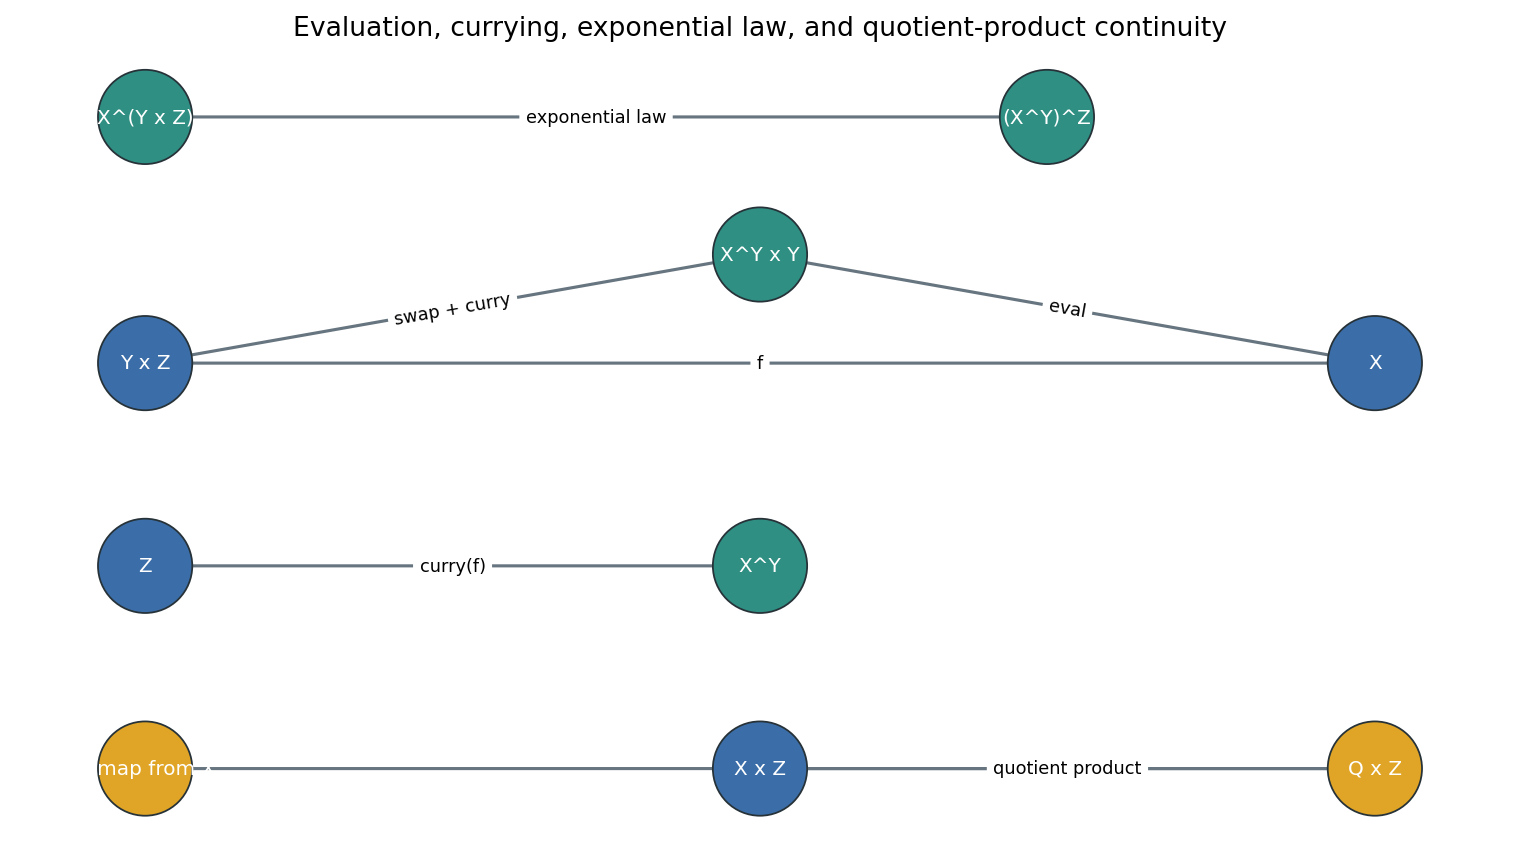

In [12]:
diagram = nx.DiGraph()
for u, v, label in [
    ("Y x Z", "X", "f"),
    ("Z", "X^Y", "curry(f)"),
    ("X^Y x Y", "X", "eval"),
    ("Y x Z", "X^Y x Y", "swap + curry"),
    ("X^(Y x Z)", "(X^Y)^Z", "exponential law"),
    ("Q map from X", "Q x Z", "q x id_Z"),
    ("X x Z", "Q x Z", "quotient product"),
]:
    diagram.add_edge(u, v, label=label)
pos = {"Y x Z": (0, 0), "X": (3, 0), "Z": (0, -1.4), "X^Y": (1.5, -1.4), "X^Y x Y": (1.5, 0.75), "X^(Y x Z)": (0, 1.7), "(X^Y)^Z": (2.2, 1.7), "Q map from X": (0, -2.8), "X x Z": (1.5, -2.8), "Q x Z": (3, -2.8)}
fig, ax = plt.subplots(figsize=(12, 6.4))
node_colors = [PALETTE["teal"] if "^" in n else PALETTE["gold"] if n.startswith("Q") else PALETTE["blue"] for n in diagram.nodes]
nx.draw_networkx_edges(diagram, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color=PALETTE["darkgray"], width=1.4)
nx.draw_networkx_nodes(diagram, pos, ax=ax, node_size=1800, node_color=node_colors, edgecolors=PALETTE["ink"], linewidths=0.8)
nx.draw_networkx_labels(diagram, pos, ax=ax, font_size=9, font_color="white")
nx.draw_networkx_edge_labels(diagram, pos, edge_labels=nx.get_edge_attributes(diagram, "label"), ax=ax, font_size=8)
ax.set_title("Evaluation, currying, exponential law, and quotient-product continuity")
ax.axis("off")
exponential_path = track(save_matplotlib(fig, FIGURES / "exponential-law-continuity-diagram.png"))
plt.close(fig)
Y = [0, 1]
Z = [0, 1, 2]
X_values = [0, 1, 2, 3]
def f_value(y, z):
    return (y + 2*z) % len(X_values)
def curry(z):
    return tuple(f_value(y, z) for y in Y)
currying_exact = all(curry(z)[Y.index(y)] == f_value(y, z) for y in Y for z in Z)
cardinality_identity = sp.Eq(len(X_values)**(len(Y)*len(Z)), (len(X_values)**len(Y))**len(Z))
quotient_fibers = {"u": {"a", "b"}, "v": {"c"}}
Z_finite = {0, 1}
product_fibers = {(q, z): {(x, z) for x in xs} for q, xs in quotient_fibers.items() for z in Z_finite}
exponential_checks = {
    "evaluation_curry_identity_on_finite_sets": currying_exact,
    "map_space_cardinality_identity": str(cardinality_identity),
    "map_space_cardinality_identity_true": bool(cardinality_identity),
    "quotient_product_equivalence_classes": {str(k): sorted(map(str, v)) for k, v in product_fibers.items()},
    "quotient_product_class_count": len(product_fibers),
    "quotient_product_class_count_expected": len(quotient_fibers) * len(Z_finite),
    "quotient_product_finite_locally_compact_sanity": len(product_fibers) == len(quotient_fibers) * len(Z_finite),
}
check_records["exponential_law"] = exponential_checks
exponential_checks_path = track(save_json(exponential_checks, CHECKS / "exponential-law-continuity-diagram.json"))
show(exponential_path, width=900)


The diagram should be read as a continuity checklist. Evaluation is continuous when the source variable is locally compact, currying is continuous exactly when the original two-variable map is continuous, and the quotient-product statement is the same kind of guarantee for homotopies defined on quotient spaces.


## Applied Lab: Tune A Hypothesis

Use the parameters below as a compact review lab. Decrease `epsilon`, move the Dowker index `k`, or replace the compact probe cells with cells farther out in the ray. The output is a small report saying which Appendix A mechanism still works and which one would need a stronger hypothesis.


In [13]:
def appendix_a_lab(epsilon_value=0.28, dowker_index=25, probe_edges=(1, 6)):
    min_radius = 1 - epsilon_value
    radial_grid = np.linspace(min_radius, 1.0, 50)
    retract_final_ok = bool(np.allclose((1 - 1.0)*radial_grid + 1.0, 1.0))
    local_b = 1.0 / (2*dowker_index + 3)
    local_t = max(dowker_index + 1, math.floor(1 / local_b) + 1, math.floor(1 / a_t) + 1)
    dowker_hit = (1.0 / local_t < a_t) and (1.0 / local_t < local_b)
    probe = {f"e{i}" for i in probe_edges}
    subcomplex = set(probe)
    for edge in list(probe):
        subcomplex.update(ray_boundary.get(edge, []))
    return {
        "epsilon_value": epsilon_value,
        "collar_has_positive_width": min_radius < 1,
        "retract_final_ok": retract_final_ok,
        "dowker_index": dowker_index,
        "dowker_constructed_hit": dowker_hit,
        "probe_edges": list(probe_edges),
        "finite_subcomplex_cell_count": len(subcomplex),
        "finite_subcomplex_boundaries_included": all(face in subcomplex for edge in subcomplex if edge in ray_boundary for face in ray_boundary[edge]),
    }

lab_report = appendix_a_lab()
check_records["applied_lab"] = lab_report
lab_path = track(save_json(lab_report, CHECKS / "appendix-a-applied-lab.json"))
print(json.dumps(lab_report, indent=2))


{
  "epsilon_value": 0.28,
  "collar_has_positive_width": true,
  "retract_final_ok": true,
  "dowker_index": 25,
  "dowker_constructed_hit": true,
  "probe_edges": [
    1,
    6
  ],
  "finite_subcomplex_cell_count": 6,
  "finite_subcomplex_boundaries_included": true
}


## Takeaways

- CW topology is controlled by characteristic maps and closed cell data; this is why many arguments can be checked skeleton by skeleton.
- Compactness is the mechanism that turns an infinite CW complex into a finite subcomplex for local arguments.
- Closure-finiteness is a real hypothesis. The disk-with-too-many-boundary-cells model shows how a plausible-looking cell decomposition can fail to be CW.
- Epsilon neighborhoods turn subcomplex arguments into open-neighborhood arguments without changing homotopy type.
- Compact generation explains why cellwise continuity tests work for maps and homotopies out of CW complexes.
- Product CW topology usually matches product topology in the common locally compact or countable cases, but Dowker's wedge shows why the distinction exists.
- ENRs, domination by CW complexes, compact-open topology, and quotient-product continuity are the point-set tools that let later homotopy theory use mapping spaces and quotients safely.


In [14]:
# final_sanity
final_required = [
    cw_skeleton_path, compact_path, failure_path, retract_path, continuity_path,
    dowker_path, enr_path, telescope_path, compact_open_path, exponential_path,
    routing_path, cw_checks_path, compact_checks_path, failure_checks_path,
    retract_checks_path, continuity_checks_path, dowker_checks_path, enr_checks_path,
    telescope_checks_path, compact_open_checks_path, exponential_checks_path, lab_path,
]
assert_artifacts(final_required, min_bytes=80)
assert SOURCE_PRINTED == (519, 532)
assert "533" in BACKMATTER_NOTE and "539" in BACKMATTER_NOTE
assert cw_checks["boundary_squared_zero"]
assert cw_checks["euler_characteristic"] == 1
assert compact_checks["all_boundaries_included"]
assert failure_checks["whitehead_condition_ii_closure_finite"] is False
assert retract_checks["final_radius_max_error"] < 1e-12
assert retract_checks["boundary_fixed_for_all_t"]
assert continuity_checks["restriction_values_compatible_on_overlaps"]
assert dowker_checks["constructed_point_inside_product_neighborhood"]
assert enr_checks["nearest_radial_retract_max_radius_error"] < 1e-12
assert telescope_checks["r_after_i_identity_on_cycle_vertices"]
assert telescope_checks["whisker_collapses_to_basepoint"]
assert compact_open_checks["g_in_displayed_basic_neighborhood"]
assert compact_open_checks["uniform_ball_implies_displayed_compact_open_membership"]
assert exponential_checks["evaluation_curry_identity_on_finite_sets"]
assert exponential_checks["map_space_cardinality_identity_true"]
assert exponential_checks["quotient_product_finite_locally_compact_sanity"]
assert lab_report["retract_final_ok"] and lab_report["dowker_constructed_hit"]
final_summary = {
    "notebook": "appendix-a-appendix/appendix-a-appendix.ipynb",
    "source_printed_pages": list(SOURCE_PRINTED),
    "backmatter_note": BACKMATTER_NOTE,
    "artifact_count": len(final_required) + 1,
    "artifacts": [rel(p) for p in final_required],
    "core_checks": {
        "boundary_squared_zero": cw_checks["boundary_squared_zero"],
        "compact_probe_in_finite_subcomplex": compact_checks["all_boundaries_included"],
        "closure_finiteness_failure_detected": not failure_checks["whitehead_condition_ii_closure_finite"],
        "deformation_retract_valid": retract_checks["final_radius_max_error"] < 1e-12,
        "dowker_product_neighborhood_hit": dowker_checks["constructed_point_inside_product_neighborhood"],
        "compact_open_uniform_membership": compact_open_checks["uniform_ball_implies_displayed_compact_open_membership"],
        "exponential_law_finite_check": exponential_checks["evaluation_curry_identity_on_finite_sets"],
    },
}
final_summary_path = track(save_json(final_summary, CHECKS / "appendix-a-final-sanity.json"))
assert_artifacts([final_summary_path], min_bytes=80)
print(json.dumps(final_summary, indent=2))


{
  "notebook": "appendix-a-appendix/appendix-a-appendix.ipynb",
  "source_printed_pages": [
    519,
    532
  ],
  "backmatter_note": "bibliography starts at printed 533; index starts at printed 539",
  "artifact_count": 23,
  "artifacts": [
    "artifacts/appendix-a-appendix/figures/cw-skeleton-characteristic-maps.png",
    "artifacts/appendix-a-appendix/figures/compact-subset-finite-subcomplex.png",
    "artifacts/appendix-a-appendix/figures/closure-finiteness-failure-mode.png",
    "artifacts/appendix-a-appendix/html/neighborhood-deformation-retract.html",
    "artifacts/appendix-a-appendix/figures/cellwise-continuity-scaffold.png",
    "artifacts/appendix-a-appendix/html/product-cw-dowker-counterexample.html",
    "artifacts/appendix-a-appendix/figures/enr-cubical-neighborhood-retract.png",
    "artifacts/appendix-a-appendix/html/mapping-telescope-domination.html",
    "artifacts/appendix-a-appendix/html/compact-open-path-neighborhoods.html",
    "artifacts/appendix-a-appendix/fi